# Maturita z matematiky → Python

**Předmět:** Science Python &nbsp;•&nbsp; **Zdroj úloh:** didaktický test CERMAT *MA_2025_TS* (jaro 2025)

Tento notebook řeší **přesně 7 úloh** maturitního testu pomocí Pythonu (knihovny
`sympy`, `numpy`, `matplotlib`). U každé úlohy uvádím podle zadání:

1. **Myšlenku řešení** (1–2 věty),
2. **Matematický zápis** (rovnice / vztah),
3. **Python kód**,
4. **Výsledek + interpretaci**.

### Výběr úloh (1 z každé kategorie)

| Kategorie | Úloha |
|---|---|
| 1. Základní výpočet (povinné) | **1** – nákup borůvek |
| 2. Algebra / úpravy | **4** – zjednodušení výrazu |
| 3. Rovnice / soustavy | **7** – soustava 3 lineárních rovnic |
| 4. Funkce a graf | **9** – kvadratická a lineární funkce |
| 5. Geometrie | **20** – zvýšení hladiny vody |
| 6. Pravděpodobnost / kombinatorika | **15** – hod dvěma kostkami |
| 7. Model / posloupnost / růst | **23** – exponenciální růst bakterií |


## Knihovny

In [1]:
%matplotlib inline
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from itertools import product
from fractions import Fraction

sp.init_printing()          # hezké zobrazení symbolických výsledků
np.set_printoptions(suppress=True)
print("Prostředí připraveno.")

Prostředí připraveno.


## Úloha 1 — Nákup borůvek (základní výpočet)

**Zadání.** První prodejce prodává 1 litr borůvek za 150 Kč, přičemž 1 litr má hmotnost 650 g.
Druhý prodejce váží: za 0,5 kg se zaplatí 120 Kč. Zákazník koupil **levnější** borůvky celkem
za 600 Kč. Za kolik korun by koupil **dražší** borůvky o stejné hmotnosti?

**Myšlenka.** Porovnám jednotkovou cenu (Kč/kg) obou prodejců, z 600 Kč u levnějšího určím
koupenou hmotnost a tu přepočítám cenou dražšího prodejce.

**Matematický zápis.**
$$c_1=\frac{150}{0{,}650}\ \text{Kč/kg},\quad c_2=\frac{120}{0{,}5}\ \text{Kč/kg},\quad
m=\frac{600}{\min(c_1,c_2)},\quad \text{cena}=m\cdot\max(c_1,c_2)$$


In [2]:
# Jednotkové ceny (Kč za kg)
c1 = 150 / 0.650      # 1. prodejce: 150 Kč za 0,650 kg
c2 = 120 / 0.5        # 2. prodejce: 120 Kč za 0,5 kg
print(f"1. prodejce: {c1:7.2f} Kč/kg")
print(f"2. prodejce: {c2:7.2f} Kč/kg")

c_levne = min(c1, c2)
c_draze = max(c1, c2)

m = 600 / c_levne                 # hmotnost koupená za 600 Kč u levnějšího
cena_draze = m * c_draze          # stejná hmotnost u dražšího prodejce

print(f"\nKoupená hmotnost:           {m:.3f} kg")
print(f"Cena u dražšího prodejce:   {cena_draze:.2f} Kč")

1. prodejce:  230.77 Kč/kg
2. prodejce:  240.00 Kč/kg

Koupená hmotnost:           2.600 kg
Cena u dražšího prodejce:   624.00 Kč


**Výsledek a interpretace.** Levnější je 1. prodejce (≈ 230,77 Kč/kg < 240,00 Kč/kg).
Za 600 Kč zákazník koupil 2,6 kg borůvek. Stejné množství by u dražšího (2.) prodejce stálo
**624 Kč**.

## Úloha 4 — Zjednodušení výrazu (algebra)

**Zadání.** Pro $a\in\mathbb{R}\setminus\{-0{,}5;\,0{,}5\}$ zjednodušte
$$(1-2a)^2 : \left(\frac{1+4a^2}{1+2a}-2a\right).$$

**Myšlenka.** Nejprve ručně sloučím závorku ve jmenovateli na jeden zlomek, pak vydělím; SymPy
použiji k symbolickému ověření a k numerické kontrole.

**Matematický zápis.**
$$\frac{1+4a^2}{1+2a}-2a=\frac{1+4a^2-2a(1+2a)}{1+2a}=\frac{1-2a}{1+2a},$$
$$(1-2a)^2:\frac{1-2a}{1+2a}=(1-2a)^2\cdot\frac{1+2a}{1-2a}=(1-2a)(1+2a)=\boxed{1-4a^2}.$$


In [3]:
a = sp.symbols('a', real=True)

vyraz = (1 - 2*a)**2 / ((1 + 4*a**2)/(1 + 2*a) - 2*a)

# mezikrok: závorka ve jmenovateli
zavorka = sp.simplify((1 + 4*a**2)/(1 + 2*a) - 2*a)
print("Závorka ve jmenovateli:", zavorka)

# celkové zjednodušení
vysledek = sp.simplify(vyraz)
print("Zjednodušený výraz:    ", vysledek)

# numerická kontrola pro a = 2
print("Kontrola a=2:", vyraz.subs(a, 2), "=?=", (1 - 4*a**2).subs(a, 2))

Závorka ve jmenovateli: (1 - 2*a)/(2*a + 1)
Zjednodušený výraz:     1 - 4*a**2
Kontrola a=2: -15 =?= -15


**Výsledek a interpretace.** Výraz se zjednoduší na **$1-4a^2$**. Podmínky $a\neq\pm0{,}5$
zaručují, že nikde nedělíme nulou (ve jmenovateli $1+2a\neq0$ a při krácení $1-2a\neq0$).
Numerická kontrola pro $a=2$ dává $-15=-15$. ✓

## Úloha 7 — Soustava lineárních rovnic

**Zadání.** Pro $x,y,z\in\mathbb{R}$ řešte
$$x+2y+z=15,\qquad x-2y+z=3,\qquad 2x+3z=9.$$

**Myšlenka.** Soustavu zapíšu maticově jako $A\mathbf{x}=\mathbf{b}$ a vyřeším dvěma způsoby —
numericky `numpy.linalg.solve` a přesně `sympy.solve`; výsledky musí souhlasit.

**Matematický zápis.**
$$A=\begin{pmatrix}1&2&1\\1&-2&1\\2&0&3\end{pmatrix},\quad
\mathbf{b}=\begin{pmatrix}15\\3\\9\end{pmatrix},\quad A\mathbf{x}=\mathbf{b}.$$


In [4]:
# --- NumPy: numerické řešení ---
A = np.array([[1,  2, 1],
              [1, -2, 1],
              [2,  0, 3]], dtype=float)
b = np.array([15, 3, 9], dtype=float)

x_num = np.linalg.solve(A, b)
print("NumPy   :  x, y, z =", x_num)
print("det(A)  :", round(np.linalg.det(A), 3), "(≠0 → právě jedno řešení)")

# --- SymPy: přesné řešení ---
x, y, z = sp.symbols('x y z')
soustava = [sp.Eq(x + 2*y + z, 15),
            sp.Eq(x - 2*y + z, 3),
            sp.Eq(2*x + 3*z, 9)]
print("SymPy   :", sp.solve(soustava, [x, y, z]))

NumPy   :  x, y, z = [18.  3. -9.]
det(A)  : -4.0 (≠0 → právě jedno řešení)
SymPy   : {x: 18, y: 3, z: -9}


**Výsledek a interpretace.** Determinant matice je nenulový, soustava má proto **jediné
řešení $x=18,\ y=3,\ z=-9$**. Numerické (NumPy) i přesné (SymPy) řešení se shodují.

## Úloha 9 — Kvadratická a lineární funkce (funkce a graf)

**Zadání.** Kvadratická funkce $f:\ y=\tfrac12 x^2-2$ má s grafem lineární funkce $g$ právě dva
společné body $A[4;\,\cdot\,]$ a $B[0;\,\cdot\,]$. Sestavte předpis $g$ a nakreslete grafy.

**Myšlenka.** Společné body leží na $f$, takže jejich $y$-ové souřadnice dopočítám dosazením
$x=4$ a $x=0$ do $f$. Dvěma body proložím přímku $g$ a ověřím, že průsečíky jsou opravdu jen dva.

**Matematický zápis.**
$$A=[4;\,f(4)]=[4;6],\quad B=[0;\,f(0)]=[0;-2],\quad
k=\frac{6-(-2)}{4-0}=2,\quad q=-2,\quad g:\ y=2x-2.$$


In [5]:
x = sp.symbols('x')
f = sp.Rational(1, 2)*x**2 - 2

# Společné body leží na f → dopočítám jejich y-souřadnice
A = (4, f.subs(x, 4))
B = (0, f.subs(x, 0))
print("A =", A, "   B =", B)

# Přímka g(x) = k*x + q proložená body A, B
k = (A[1] - B[1]) / (A[0] - B[0])
q = B[1]                      # B leží na ose y, takže q = y_B
g = k*x + q
print("g(x) =", g)

# Kontrola: kolik mají f a g společných bodů?
prusecik_x = sp.solve(sp.Eq(f, g), x)
print("Průsečíky pro x =", prusecik_x)

A = (4, 6)    B = (0, -2)
g(x) = 2*x - 2
Průsečíky pro x = [0, 4]


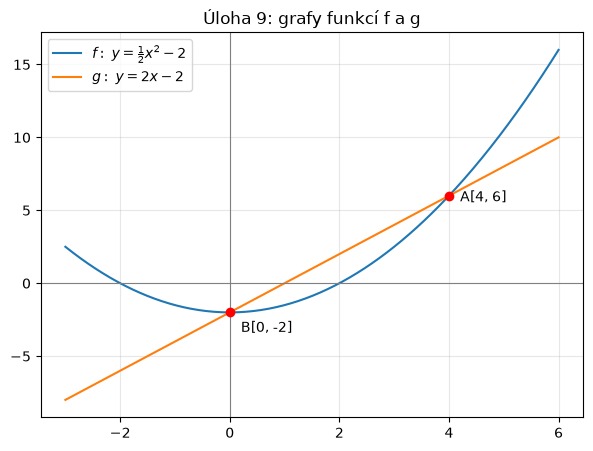

In [6]:
# --- Graf ---
f_num = sp.lambdify(x, f, 'numpy')
g_num = sp.lambdify(x, g, 'numpy')
xs = np.linspace(-3, 6, 400)

plt.figure(figsize=(7, 5))
plt.plot(xs, f_num(xs), label=r'$f:\ y=\frac{1}{2}x^2-2$')
plt.plot(xs, g_num(xs), label=r'$g:\ y=2x-2$')
plt.scatter([A[0], B[0]], [float(A[1]), float(B[1])], color='red', zorder=5)
plt.annotate('A[4, 6]', (A[0], float(A[1])), textcoords="offset points", xytext=(8, -4))
plt.annotate('B[0, -2]', (B[0], float(B[1])), textcoords="offset points", xytext=(8, -14))
plt.axhline(0, color='gray', lw=.8)
plt.axvline(0, color='gray', lw=.8)
plt.grid(alpha=.3); plt.legend(); plt.title('Úloha 9: grafy funkcí f a g')
plt.savefig('img/uloha9_graf.png', dpi=110, bbox_inches='tight')
plt.show()

**Výsledek a interpretace.** Hledaná lineární funkce je **$g:\ y=2x-2$**. Společné body jsou
$A[4;6]$ a $B[0;-2]$. Rovnice $\tfrac12 x^2-2=2x-2$ vede na $x^2-4x=0$, tedy $x\in\{0;4\}$ —
graf má opravdu **právě dva** společné body, jak vyžaduje zadání.

## Úloha 20 — Zvýšení hladiny vody (geometrie)

**Zadání.** Nádoba je rotační válec o průměru 12 cm a výšce 16 cm; voda sahá do výšky 11 cm.
Vhodíme kovovou kuličku o poloměru 3 cm. Kulička klesne ke dnu — o kolik stoupne hladina?

**Myšlenka.** Celá ponořená kulička vytlačí vodu o objemu rovném svému objemu; ten se rozprostře
po konstantním průřezu válce, takže přírůstek výšky = objem kuličky / obsah průřezu.

**Matematický zápis.**
$$V_{\text{koule}}=\tfrac{4}{3}\pi r_k^3,\quad S_{\text{válec}}=\pi r_v^2,\quad
\Delta h=\frac{V_{\text{koule}}}{S_{\text{válec}}}.$$


In [7]:
r_kulicka = 3      # poloměr kuličky [cm]
r_valec   = 6      # poloměr válce (průměr 12 cm) [cm]

V_kulicka = sp.Rational(4, 3) * sp.pi * r_kulicka**3
S_valec   = sp.pi * r_valec**2
dh        = sp.simplify(V_kulicka / S_valec)

print("Objem kuličky:        ", V_kulicka, "cm^3")
print("Obsah průřezu válce:  ", S_valec, "cm^2")
print("Δh =", dh, "cm =", float(dh), "cm")

# kontroly platnosti modelu
print("\nKulička je celá ponořená (2r =", 2*r_kulicka, "cm < 11 cm vody):",
      2*r_kulicka < 11)
print("Voda nepřeteče (nová hladina", 11 + float(dh), "cm <= 16 cm):",
      11 + float(dh) <= 16)

Objem kuličky:         36*pi cm^3
Obsah průřezu válce:   36*pi cm^2
Δh = 1 cm = 1.0 cm

Kulička je celá ponořená (2r = 6 cm < 11 cm vody): True
Voda nepřeteče (nová hladina 12.0 cm <= 16 cm): True


**Výsledek a interpretace.** Hladina stoupne o **1,00 cm** (odpověď D). Objem kuličky
$36\pi\ \text{cm}^3$ je shodou okolností číselně stejný jako obsah průřezu $36\pi\ \text{cm}^2$,
proto $\Delta h=1$ cm. Kulička se celá ponoří (průměr 6 cm < 11 cm) a voda nepřeteče
(11 + 1 = 12 cm ≤ 16 cm).

## Úloha 15 — Hod dvěma kostkami (pravděpodobnost)

**Zadání.** Kostka A je šestistěnná (1–6), kostka B osmistěnná (1–8), obě spravedlivé. Jevy:
**X** = na obou padne liché číslo, **Y** = součet je lichý, **Z** = součet je sudý.
Rozhodněte (A/N):  15.1 $P(X)=0{,}25$;  15.2 $P(Y)=P(X)$;  15.3 $P(Z)>P(Y)$.

**Myšlenka.** Vyčíslím přesné pravděpodobnosti vypsáním všech $6\cdot8=48$ stejně pravděpodobných
dvojic (přesné zlomky přes `Fraction`) a navíc ověřím simulací (Monte Carlo, milion hodů).

**Matematický zápis.**
$$|\Omega|=48,\quad P(X)=\frac{3\cdot4}{48}=\frac14,\quad
P(Y)=\frac{24}{48}=\frac12,\quad P(Z)=1-P(Y)=\frac12.$$


In [8]:
omega = list(product(range(1, 7), range(1, 9)))   # všech 48 dvojic (a, b)
N = len(omega)

X = [(a, b) for a, b in omega if a % 2 == 1 and b % 2 == 1]   # obě liché
Y = [(a, b) for a, b in omega if (a + b) % 2 == 1]            # součet lichý
Z = [(a, b) for a, b in omega if (a + b) % 2 == 0]            # součet sudý

PX, PY, PZ = Fraction(len(X), N), Fraction(len(Y), N), Fraction(len(Z), N)
print(f"P(X) = {PX} = {float(PX)}")
print(f"P(Y) = {PY} = {float(PY)}")
print(f"P(Z) = {PZ} = {float(PZ)}")

print("\n15.1  P(X) = 0,25 ?   ", "A" if float(PX) == 0.25 else "N")
print("15.2  P(Y) = P(X) ?   ", "A" if PY == PX else "N")
print("15.3  P(Z) > P(Y) ?   ", "A" if PZ > PY else "N")

P(X) = 1/4 = 0.25
P(Y) = 1/2 = 0.5
P(Z) = 1/2 = 0.5

15.1  P(X) = 0,25 ?    A
15.2  P(Y) = P(X) ?    N
15.3  P(Z) > P(Y) ?    N


In [9]:
# --- Ověření simulací (Monte Carlo) ---
rng = np.random.default_rng(0)
n = 1_000_000
d1 = rng.integers(1, 7, n)     # 1..6
d2 = rng.integers(1, 9, n)     # 1..8

print("sim P(X) =", round(float(np.mean((d1 % 2 == 1) & (d2 % 2 == 1))), 4))
print("sim P(Y) =", round(float(np.mean((d1 + d2) % 2 == 1)), 4))
print("sim P(Z) =", round(float(np.mean((d1 + d2) % 2 == 0)), 4))

sim P(X) = 0.2505
sim P(Y) = 0.4997
sim P(Z) = 0.5003


**Výsledek a interpretace.**
- **15.1 → A**: $P(X)=\tfrac{3\cdot4}{48}=0{,}25$.
- **15.2 → N**: $P(Y)=0{,}5\neq0{,}25=P(X)$.
- **15.3 → N**: $P(Z)=0{,}5$ **není větší** než $P(Y)=0{,}5$ (jsou stejné).

Simulace milionu hodů dává hodnoty ≈ 0,25 / 0,50 / 0,50, což přesné výsledky potvrzuje.

## Úloha 23 — Exponenciální růst bakterií (model / růst)

**Zadání.** Růst bakterií je za stálých podmínek exponenciální; za každých 24 hodin vzroste počet
**64krát**. Za jak dlouho vzroste počet **4krát**?

**Myšlenka.** Exponenciální model $N(t)=N_0\cdot 64^{\,t/24}$; hledám čas $t$, kdy je poměr roven 4,
tj. řeším $64^{\,t/24}=4$ logaritmováním.

**Matematický zápis.**
$$64^{\,t/24}=4 \;\Rightarrow\; \frac{t}{24}\ln 64=\ln 4
\;\Rightarrow\; t=24\cdot\frac{\ln 4}{\ln 64}=24\cdot\frac{\ln 4}{3\ln 4}=8\ \text{h}.$$


In [10]:
t = sp.symbols('t', positive=True)

reseni  = sp.solve(sp.Eq(64**(t/24), 4), t)          # přímo rovnice
t_log   = sp.simplify(24*sp.log(4)/sp.log(64))       # přes logaritmus
print("t (sympy.solve)     =", reseni, "h")
print("t (přes logaritmus) =", t_log, "h")

# kontrola: za 8 h je nárůst opravdu 4×  (64 = 4^3, tedy 64^(1/3) = 4)
print("Ověření 64^(8/24)   =", 64**sp.Rational(8, 24))

t (sympy.solve)     = [8] h
t (přes logaritmus) = 8 h
Ověření 64^(8/24)   = 4


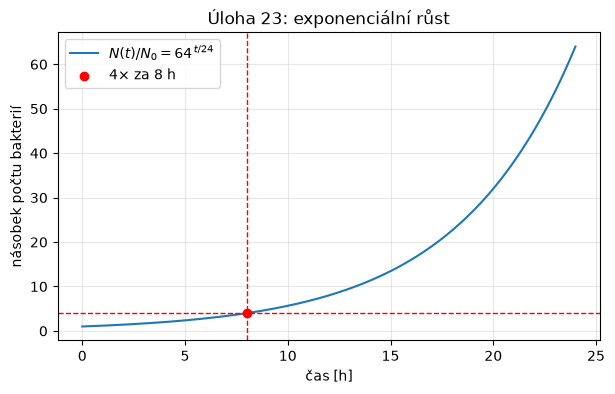

In [11]:
# --- Graf růstu (násobek počátečního počtu během 24 h) ---
ts = np.linspace(0, 24, 200)
plt.figure(figsize=(7, 4))
plt.plot(ts, 64**(ts/24), label=r'$N(t)/N_0 = 64^{\,t/24}$')
plt.axhline(4, color='red', ls='--', lw=1)
plt.axvline(8, color='red', ls='--', lw=1)
plt.scatter([8], [4], color='red', zorder=5, label='4× za 8 h')
plt.xlabel('čas [h]'); plt.ylabel('násobek počtu bakterií')
plt.grid(alpha=.3); plt.legend(); plt.title('Úloha 23: exponenciální růst')
plt.savefig('img/uloha23_graf.png', dpi=110, bbox_inches='tight')
plt.show()

**Výsledek a interpretace.** Počet bakterií vzroste 4× za **8 hodin** (odpověď D). Protože
$64=4^3$, platí $64^{\,t/24}=4$ právě když $\tfrac{t}{24}=\tfrac13$, tedy $t=8$ h.

---
### Shrnutí výsledků

| Úloha | Výsledek |
|---|---|
| 1 — borůvky | **624 Kč** |
| 4 — výraz | **$1-4a^2$** |
| 7 — soustava | **$x=18,\ y=3,\ z=-9$** |
| 9 — funkce | **$g:\ y=2x-2$**, body $A[4;6],\ B[0;-2]$ |
| 20 — hladina | **+1,00 cm** (D) |
| 15 — kostky | **A, N, N** |
| 23 — bakterie | **8 hodin** (D) |
